In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import gc
sns.set_theme()
gc.enable()

In [2]:
main_data=pd.read_csv('application_train.csv')
main_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
main_data.shape

(307511, 122)

## Distribution of Target

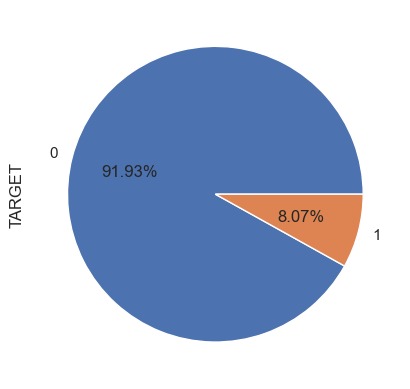

In [4]:
main_data['TARGET'].value_counts().plot.pie(autopct='%1.2f%%');

# Single Variables With Target

In [5]:
def plot_category_vs_target(feature):    
    data=main_data[feature] #extract the needed column
    values=main_data[feature].unique() #store the unique values
    fig, axs=plt.subplots(nrows=values.shape[0])
    fig.set_size_inches(6, 4*values.shape[0])
    for i, value in enumerate(values):
        temp=main_data[data==value] #extraxt the needed subset
        total=temp.shape[0]
        plot_data=temp['TARGET'].value_counts()*100/total
        plot_data.rename(index={0: "Paid", 1: "Defaulted"}, inplace=True)
        axs[i].pie(x=plot_data.values, labels=plot_data.index, autopct='%1.1f%%')
        axs[i].set_title("Defaulters in %s"%value)

## Loan Type

In [6]:
total=main_data.shape[0]
main_data['NAME_CONTRACT_TYPE'].value_counts()*100/total

Cash loans         90.478715
Revolving loans     9.521285
Name: NAME_CONTRACT_TYPE, dtype: float64

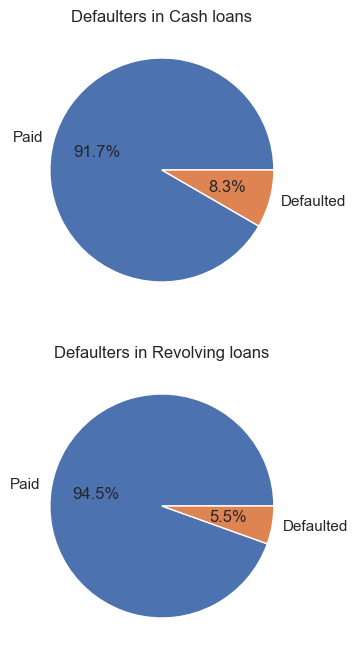

In [7]:
plot_category_vs_target('NAME_CONTRACT_TYPE')

In [8]:
def chi2_categorical(feature):
    observed=pd.crosstab(main_data[feature], main_data['TARGET'])
    print(observed)
    res=chi2_contingency(observed)
    print(res)

chi2_categorical('NAME_CONTRACT_TYPE')

TARGET                   0      1
NAME_CONTRACT_TYPE               
Cash loans          255011  23221
Revolving loans      27675   1604
Chi2ContingencyResult(statistic=293.15054219964554, pvalue=1.0235150721172847e-65, dof=1, expected_freq=array([[255770.65910488,  22461.34089512],
       [ 26915.34089512,   2363.65910488]]))


## Gender

In [9]:
main_data['CODE_GENDER'].value_counts()*100/total

F      65.834393
M      34.164306
XNA     0.001301
Name: CODE_GENDER, dtype: float64

In [10]:
main_data.replace(to_replace={'CODE_GENDER':{'XNA': 'F'}}, inplace=True)
main_data['CODE_GENDER'].value_counts()*100/total

F    65.835694
M    34.164306
Name: CODE_GENDER, dtype: float64

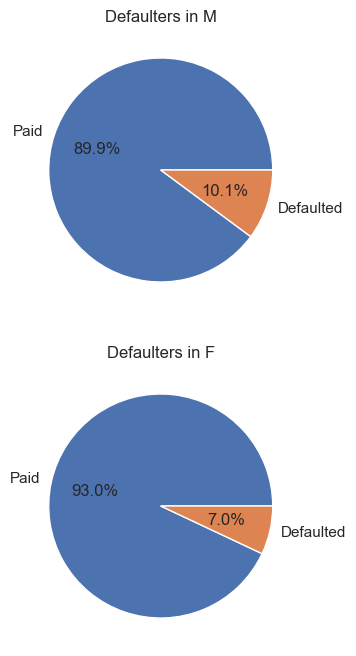

In [11]:
plot_category_vs_target('CODE_GENDER')

## Days Birth

In [12]:
main_data['DAYS_BIRTH'].describe()

count    307511.000000
mean     -16036.995067
std        4363.988632
min      -25229.000000
25%      -19682.000000
50%      -15750.000000
75%      -12413.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64

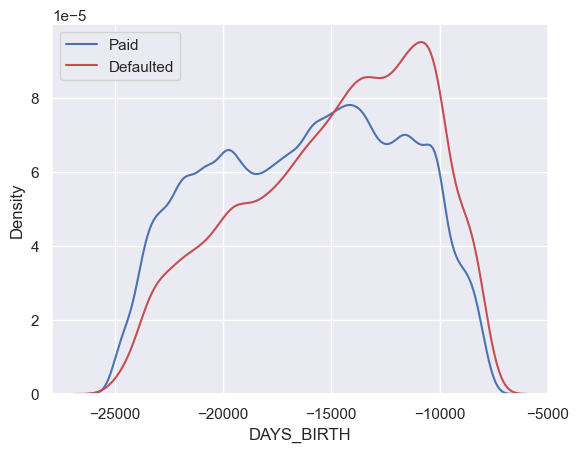

In [33]:
def plot_kde_vs_target(feature):
    paid=main_data[main_data['TARGET']==0][feature]
    defaulted=main_data[main_data['TARGET']==1][feature]
    sns.kdeplot(paid, label='Paid', color='b')
    sns.kdeplot(defaulted, label='Defaulted', color='r')
    plt.legend()

plot_kde_vs_target('DAYS_BIRTH')